# 02 — Forecasting Baselines

This notebook builds simple forecasting baselines at the **Store + Dept + Date** grain. We engineer time features, split data chronologically, and compare naive methods against a linear regression model.

**Libraries:** pandas, scikit-learn, matplotlib, seaborn


In [4]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")

DATA_PATH = "../data/"

train = pd.read_csv(f"{DATA_PATH}train.csv", parse_dates=["Date"])
features = pd.read_csv(f"{DATA_PATH}features.csv", parse_dates=["Date"], na_values=["NA"])
stores = pd.read_csv(f"{DATA_PATH}stores.csv")

for df in [train, features]:
    df["IsHoliday"] = df["IsHoliday"].map({"TRUE": True, "FALSE": False, True: True, False: False})

print(f"Train period: {train['Date'].min().date()} to {train['Date'].max().date()}")


Train period: 2010-02-05 to 2012-10-26


## 1. Prepare Modeling Dataset

In [5]:
%matplotlib inline
# Store-level features joined to each department row
model_df = (
    train
    .merge(features.drop(columns=["IsHoliday"]), on=["Store", "Date"], how="left")
    .merge(stores, on="Store", how="left")
    .sort_values(["Store", "Dept", "Date"])
    .reset_index(drop=True)
)

print(f"Modeling rows: {model_df.shape[0]:,}")
print(f"Date range: {model_df['Date'].min().date()} to {model_df['Date'].max().date()}")
model_df.head()


Modeling rows: 421,570
Date range: 2010-02-05 to 2012-10-26


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


## 2. Feature Engineering

Simple calendar features capture seasonality. Lag and rolling features use only past values within each Store + Dept series (no leakage).


In [6]:
%matplotlib inline
model_df["year"] = model_df["Date"].dt.year
model_df["month"] = model_df["Date"].dt.month
model_df["week"] = model_df["Date"].dt.isocalendar().week.astype(int)
model_df["is_holiday"] = model_df["IsHoliday"].astype(int)

# Promotional intensity (nullable early in history)
markdown_cols = [c for c in model_df.columns if c.startswith("MarkDown")]
model_df["total_markdown"] = model_df[markdown_cols].sum(axis=1, skipna=True)

# Lags and rolling mean by Store + Dept
for lag in [1, 4]:
    model_df[f"lag_{lag}"] = model_df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(lag)

model_df["rolling_mean_4"] = (
    model_df.groupby(["Store", "Dept"])["Weekly_Sales"]
    .transform(lambda s: s.shift(1).rolling(4, min_periods=1).mean())
)

# Seasonal naive needs same week last year (52 weeks back)
model_df["lag_52"] = model_df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(52)

feature_preview = model_df[[
    "Store", "Dept", "Date", "Weekly_Sales", "year", "month", "week",
    "is_holiday", "lag_1", "lag_4", "rolling_mean_4", "lag_52"
]].tail(3)
feature_preview


,Store,Dept,Date,Weekly_Sales,year,month,week,is_holiday,lag_1,lag_4,rolling_mean_4,lag_52
421567,45,98,2012-10-12,1061.02,2012,10,41,0,628.10,605.96,552.4325,996.40
421568,45,98,2012-10-19,760.01,2012,10,42,0,1061.02,467.30,666.1975,1058.84
421569,45,98,2012-10-26,1076.80,2012,10,43,0,760.01,508.37,739.3750,1167.90


## 3. Time-Based Train / Validation Split

We hold out the **last 12 weeks** of the training period as validation. This mimics real forecasting — the model never sees future dates during training.


In [7]:
%matplotlib inline
cutoff_date = model_df["Date"].max() - pd.Timedelta(weeks=12)
print(f"Validation cutoff: {cutoff_date.date()}")

train_mask = model_df["Date"] <= cutoff_date
valid_mask = model_df["Date"] > cutoff_date

train_set = model_df.loc[train_mask].copy()
valid_set = model_df.loc[valid_mask].copy()

print(f"Train rows: {len(train_set):,} | Validation rows: {len(valid_set):,}")


Validation cutoff: 2012-08-03
Train rows: 386,007 | Validation rows: 35,563


## 4. Baseline Models

Three baselines:
1. **Naive last value** — predict last week's sales (`lag_1`)
2. **Seasonal naive** — predict same week last year (`lag_52`), where available
3. **Linear regression** — simple model using time, holiday, lags, and store type


In [8]:
%matplotlib inline
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1, None))) * 100
    return {"model": label, "MAE": mae, "RMSE": rmse, "MAPE": mape}


# Drop rows without lag_1 (first week per series)
valid_eval = valid_set.dropna(subset=["lag_1"]).copy()
y_true = valid_eval["Weekly_Sales"]

# 1) Naive last value
pred_naive = valid_eval["lag_1"]
metrics_naive = evaluate(y_true, pred_naive, "Naive (last value)")

# 2) Seasonal naive (52-week lag)
valid_seasonal = valid_eval.dropna(subset=["lag_52"]).copy()
y_true_seasonal = valid_seasonal["Weekly_Sales"]
pred_seasonal = valid_seasonal["lag_52"]
metrics_seasonal = evaluate(y_true_seasonal, pred_seasonal, "Seasonal naive (lag 52)")

# 3) Linear regression
feature_cols = [
    "year", "month", "week", "is_holiday",
    "lag_1", "lag_4", "rolling_mean_4",
    "Temperature", "Fuel_Price", "CPI", "Unemployment", "total_markdown",
]
cat_cols = ["Type"]
train_lr = train_set.dropna(subset=["lag_1"]).copy()
valid_lr = valid_eval.copy()

X_train = pd.get_dummies(train_lr[feature_cols + cat_cols], columns=cat_cols, drop_first=True)
X_valid = pd.get_dummies(valid_lr[feature_cols + cat_cols], columns=cat_cols, drop_first=True)
X_valid = X_valid.reindex(columns=X_train.columns, fill_value=0)

lr = LinearRegression()
lr.fit(X_train.fillna(0), train_lr["Weekly_Sales"])
pred_lr = lr.predict(X_valid.fillna(0))
metrics_lr = evaluate(y_true, pred_lr, "Linear regression")

results = pd.DataFrame([metrics_naive, metrics_seasonal, metrics_lr])
results[["MAE", "RMSE", "MAPE"]] = results[["MAE", "RMSE", "MAPE"]].round(2)
results


,model,MAE,RMSE,MAPE
0,Naive (last value),1500.61,3428.93,80.23
1,Seasonal naive (lag 52),1764.25,3774.60,164.67
2,Linear regression,1540.24,3316.82,441.68


## 5. Actual vs Predicted (Sample Series)

Charts for a few Store + Dept combinations show where baselines track seasonality and where they miss spikes.


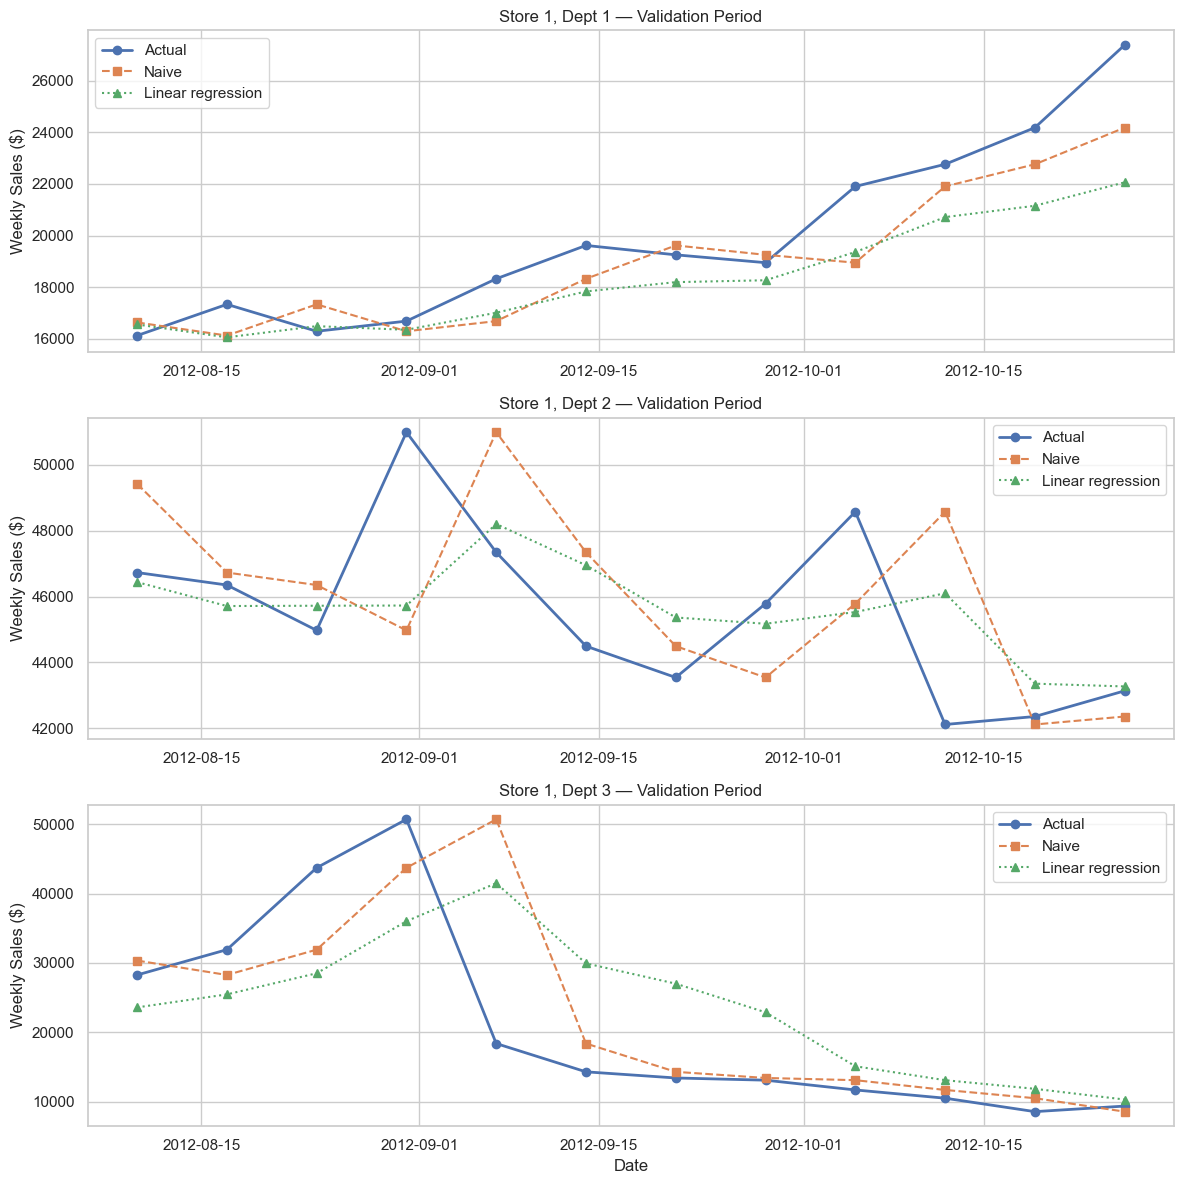

In [9]:
%matplotlib inline
valid_eval = valid_eval.copy()
valid_eval["pred_naive"] = valid_eval["lag_1"]
valid_eval["pred_lr"] = pred_lr

sample_pairs = valid_eval.groupby(["Store", "Dept"]).size().nlargest(3).index.tolist()

fig, axes = plt.subplots(len(sample_pairs), 1, figsize=(12, 4 * len(sample_pairs)), sharex=False)
if len(sample_pairs) == 1:
    axes = [axes]

for ax, (store, dept) in zip(axes, sample_pairs):
    subset = valid_eval[(valid_eval["Store"] == store) & (valid_eval["Dept"] == dept)].sort_values("Date")
    ax.plot(subset["Date"], subset["Weekly_Sales"], marker="o", label="Actual", linewidth=2)
    ax.plot(subset["Date"], subset["pred_naive"], marker="s", linestyle="--", label="Naive")
    ax.plot(subset["Date"], subset["pred_lr"], marker="^", linestyle=":", label="Linear regression")
    ax.set_title(f"Store {store}, Dept {dept} — Validation Period")
    ax.set_ylabel("Weekly Sales ($)")
    ax.legend()

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


## Conclusion

The baseline models capture the overall direction of weekly sales but do not perform well on sudden changes or highly volatile department-level series.

The naive model serves as a strong reference benchmark, while linear regression produces smoother forecasts that often miss local peaks and drops. External features such as temperature, fuel price, CPI, and unemployment show only weak standalone relationships with sales, while markdown activity appears somewhat more informative.

This confirms that simple baselines are useful for benchmarking, but better forecasting performance will likely require richer lag-based and seasonal features.